In [2]:
from description import DescriptionEntry, row_to_object
import csv

In [3]:
# Create a list to store all your objects
all_entries = []

# Open the CSV file
# Ensure the filename matches your actual file
filename = 'results-updated-eval.csv' 

with open(filename, mode='r', encoding='utf-8') as csvfile:
    # DictReader automatically uses the header row as keys
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        # Convert row to object
        entry = row_to_object(row)
        all_entries.append(entry)

# --- Example: Loop through and print specific attributes ---
for entry in all_entries[:3]: # Printing just first 3 to avoid cluttering notebook
    print("-" * 50)
    print(f"Test ID:      {entry.test_id}")
    print(f"Dataset:      {entry.dataset_name} (ID: {entry.dataset_id})")
    print(f"Prompt:       {entry.prompt}")
    print(f"Strategy:     {entry.extraction_strategy}")
    
    print("\n--- Profile Stats (from JSON) ---")
    print(f"Summary:      {entry.profile_stats.summary[:50]}...") # Truncated for display
    print(f"Src Length:   {entry.profile_stats.source_length}")
    
    print("\n--- Scores ---")
    print(f"Completeness: {entry.completeness_score}")
    print(f"Readability:  {entry.readability_score}")
    
    print("\n--- BERT Metrics ---")
    # Accessing dictionary values
    print(f"Precision:    {entry.bert_metrics['precision']}")
    print(f"F1:           {entry.bert_metrics['f1']}")
    
    print("\n--- Strict Coverage ---")
    print(f"Overall:      {entry.strict_coverage['overall']}")
    print(f"Provenance:   {entry.strict_coverage['provenance']}")
    print("-" * 50)

--------------------------------------------------
Test ID:      Augmented_AutoDDG-180955
Dataset:      The FluPRINT database (ID: The FluPRINT database)
Prompt:       Research_shortv1
Strategy:     full

--- Profile Stats (from JSON) ---
Summary:      This is a scientific article about a study on the ...
Src Length:   76710

--- Scores ---
Completeness: 9.0
Readability:  8.0

--- BERT Metrics ---
Precision:    0.7727652192115784
F1:           0.7920626401901245

--- Strict Coverage ---
Overall:      0.0
Provenance:   0.0
--------------------------------------------------
--------------------------------------------------
Test ID:      Augmented_AutoDDG-180959
Dataset:      The FluPRINT database (ID: The FluPRINT database)
Prompt:       Research_shortv1
Strategy:     keyword

--- Profile Stats (from JSON) ---
Summary:      Here's how "The FluPRINT database" was used in the...
Src Length:   12211

--- Scores ---
Completeness: 9.0
Readability:  9.0

--- BERT Metrics ---
Precision:    0.8

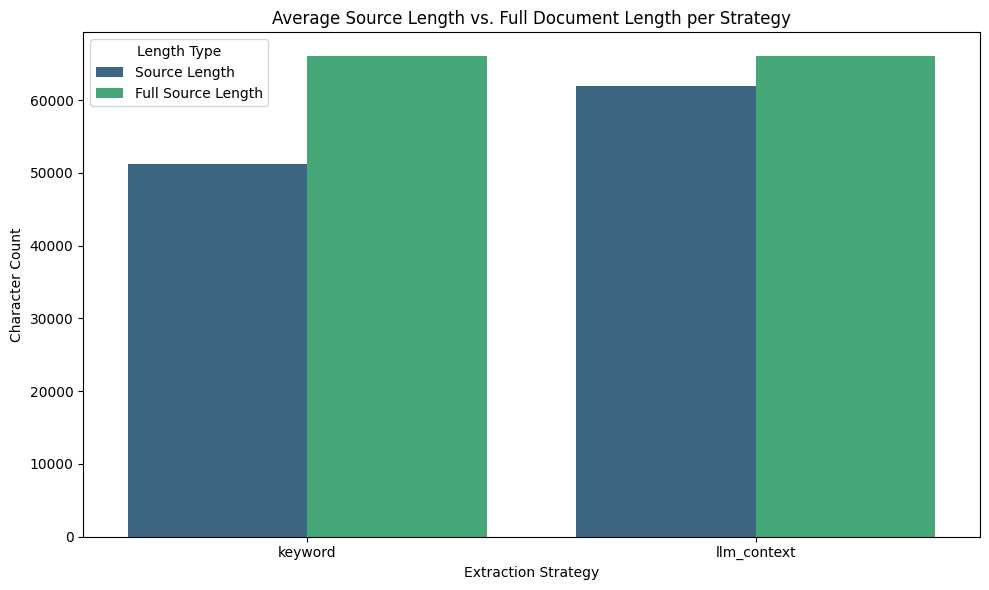

  Extraction Strategy  Source Length  Full Source Length
0             keyword        51199.2             66025.4
1         llm_context        61890.3             66025.4


In [11]:
# --- 3. Process Data using Objects ---
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('results-updated-1-eval.csv')

entries = [row_to_object(row) for index, row in df.iterrows()]

# --- 4. Prepare for Plotting ---
# We extract the specific fields needed for the length comparison
plot_data = []
for entry in entries:
    plot_data.append({
        'Extraction Strategy': entry.extraction_strategy,
        'Source Length': entry.profile_stats.source_length,
        'Full Source Length': entry.profile_stats.full_source_length
    })

plot_df = pd.DataFrame(plot_data)

# Aggregate by Strategy (calculate mean) in case there are multiple entries
agg_df = plot_df.groupby('Extraction Strategy').mean().reset_index()

# Melt for Seaborn (Long format)
melted_df = agg_df.melt(
    id_vars='Extraction Strategy',
    value_vars=['Source Length', 'Full Source Length'],
    var_name='Length Type',
    value_name='Character Count'
)

# --- 5. Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=melted_df,
    x='Extraction Strategy',
    y='Character Count',
    hue='Length Type',
    palette='viridis'
)

plt.title('Average Source Length vs. Full Document Length per Strategy')
plt.ylabel('Character Count')
plt.xlabel('Extraction Strategy')
plt.tight_layout()
plt.show()

# Print Table for verification
print(agg_df)

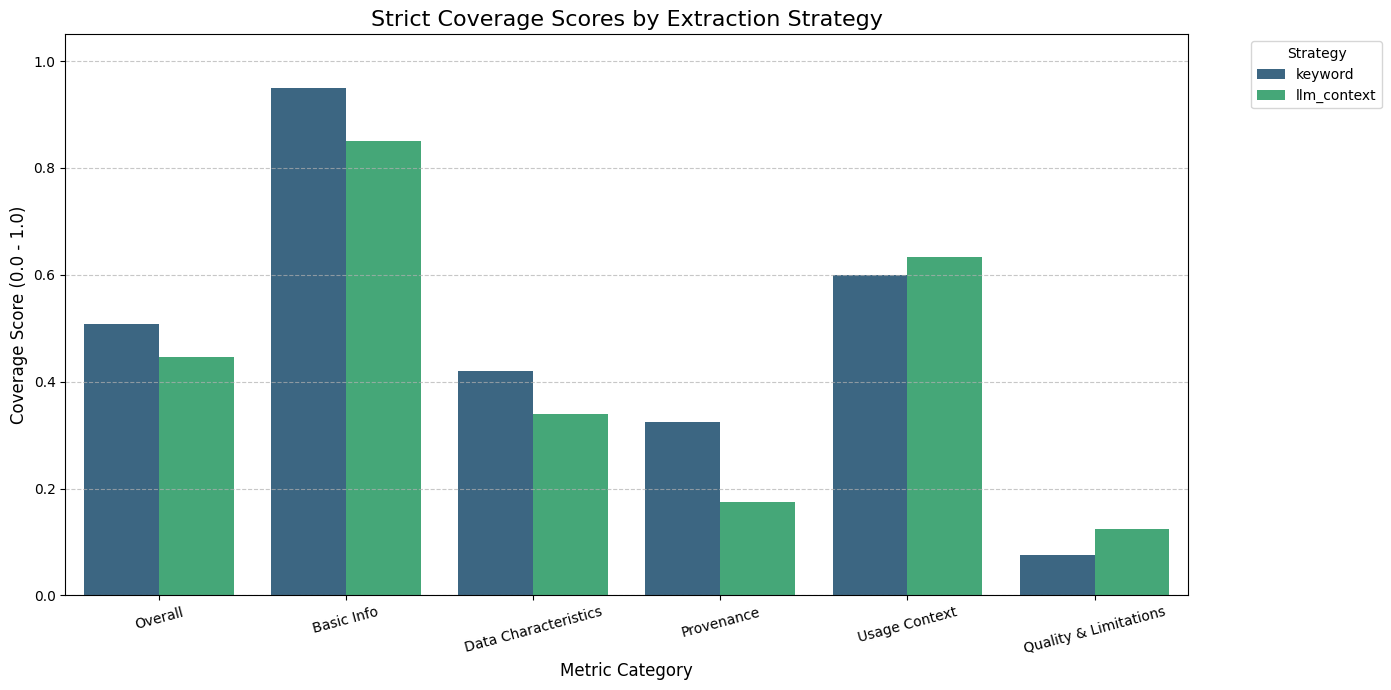

Average Strict Coverage Scores per Strategy:


,Overall,Basic Info,Data Characteristics,Provenance,Usage Context,Quality & Limitations
Strategy,,,,,,
keyword,0.508500,0.95,0.42,0.325,0.600000,0.075
llm_context,0.446167,0.85,0.34,0.175,0.633333,0.125


In [14]:
coverage_data = []

for entry in entries:
    # We pull from 'strict_coverage' (change to 'lenient_coverage' if you prefer that)
    cov = entry.strict_coverage
    
    coverage_data.append({
        'Strategy': entry.extraction_strategy,
        'Overall': cov['overall'],
        'Basic Info': cov['basic_info'],
        'Data Characteristics': cov['data_characteristics'],
        'Provenance': cov['provenance'],
        'Usage Context': cov['usage_context'],
        'Quality & Limitations': cov['quality_and_limitations']
    })

# 2. Convert to DataFrame
df_cov = pd.DataFrame(coverage_data)

# 3. Reshape for Plotting (Long Format)
# We want to group by 'Metric' on the X-axis
df_melted = df_cov.melt(
    id_vars='Strategy', 
    var_name='Coverage Metric', 
    value_name='Score'
)

# 4. Create the Plot
plt.figure(figsize=(14, 7))

# Helper: Define order so 'Overall' is first
order = ['Overall', 'Basic Info', 'Data Characteristics', 'Provenance', 'Usage Context', 'Quality & Limitations']

sns.barplot(
    data=df_melted,
    x='Coverage Metric',
    y='Score',
    hue='Strategy',
    order=order,
    palette='viridis',
    errorbar=None  # Removes error bars for cleaner look (optional: change to 'sd' for std dev)
)

plt.title('Strict Coverage Scores by Extraction Strategy', fontsize=16)
plt.ylabel('Coverage Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Metric Category', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1.05)  # Slight buffer above 1.0
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Print Summary Table (Averages)
print("Average Strict Coverage Scores per Strategy:")
summary_table = df_cov.groupby('Strategy').mean()
display(summary_table[order])

In [13]:
length_data = []

for entry in entries:
    src_len = entry.profile_stats.source_length
    full_len = entry.profile_stats.full_source_length
    
    # Avoid division by zero
    ratio = (src_len / full_len) * 100 if full_len > 0 else 0
    
    length_data.append({
        'Strategy': entry.extraction_strategy,
        'Context Sent (Chars)': src_len,
        'Full Paper (Chars)': full_len,
        'Ratio (%)': ratio
    })

# 2. Convert to DataFrame
df_len = pd.DataFrame(length_data)

# 3. Create the Summary Table (Averages)
# We group by strategy to see the "Average Cost" of each approach
summary_table = df_len.groupby('Strategy').mean().reset_index()

# Formatting for readability
summary_table['Context Sent (Chars)'] = summary_table['Context Sent (Chars)'].map('{:,.0f}'.format)
summary_table['Full Paper (Chars)'] = summary_table['Full Paper (Chars)'].map('{:,.0f}'.format)
summary_table['Ratio (%)'] = summary_table['Ratio (%)'].map('{:.1f}%'.format)

# Rename columns for the final display
summary_table = summary_table.rename(columns={
    'Strategy': 'Extraction Strategy',
    'Context Sent (Chars)': 'Avg Context Sent',
    'Full Paper (Chars)': 'Avg Full Paper Length'
})

print("--- Context vs. Full Text Comparison ---")
display(summary_table)

--- Context vs. Full Text Comparison ---


,Extraction Strategy,Avg Context Sent,Avg Full Paper Length,Ratio (%)
0,keyword,"51,199","66,025",78.5%
1,llm_context,"61,890","66,025",94.1%
